# Prediccion Semanal de Tweets — Elon Musk (Mejorado)

Predice el numero de **tweets por semana** de Elon Musk usando su historial.

### Mejoras respecto al notebook base
| Aspecto | Base | Mejorado |
|---------|------|----------|
| N_LAGS (modelos simples) | 4 | **6** |
| Random Forest | 100 est., max_depth=5 | **300 est., max_depth=10** |
| Red Neuronal Simple | 1 capa (2 neuronas) | **3 capas (64→32→16) + BN + Dropout** |
| SEQ_LEN (RNN) | 12 semanas | **16 semanas** |
| LSTM | 1 capa (64 u.) | **Stacked 2 capas (128→64) + Dense(32) + L2** |
| GRU | 1 capa (32 u.) | **Stacked 2 capas (64→32) + Dense(16) + L2** |
| BiLSTM+GRU | 32 u. | **64 u. + Dense(32) + L2** |
| LSTM+Regimen | 32 u. | **Stacked 2 capas (128→64) + Dense(32) + L2** |
| EarlyStopping patience | 50 | **60** |
| ReduceLR factor/patience | 0.3/10 | **0.5/15** |
| BATCH_SIZE | 16 | **32** |

## 0. Instalacion de dependencias

In [31]:
#!pip install tensorflow pandas numpy matplotlib scikit-learn -q

## 1. Imports y configuracion

In [32]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

print('TensorFlow:', tf.__version__)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

TensorFlow: 2.15.0


## 2. Carga de datos y agregacion semanal

In [33]:
csv_path = 'data/raw/all_musk_posts.csv'
df = pd.read_csv(csv_path, low_memory=False)
df['createdAt'] = pd.to_datetime(df['createdAt'], utc=True)
df['createdAt_naive'] = df['createdAt'].dt.tz_localize(None)
df['week'] = df['createdAt_naive'].dt.to_period('W').apply(lambda r: r.start_time)

weekly = (
    df.groupby('week').size()
    .reset_index(name='tweet_count')
)
weekly = weekly[weekly['week'] >= '2018-01-01'].copy().reset_index(drop=True)

print(f'Semanas: {len(weekly)}')
print(f'Rango: {weekly["week"].min().date()} -> {weekly["week"].max().date()}')
print(f'Media: {weekly["tweet_count"].mean():.1f}  Max: {weekly["tweet_count"].max()}')


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Semanas: 380
Rango: 2018-01-01 -> 2025-04-07
Media: 134.4  Max: 671


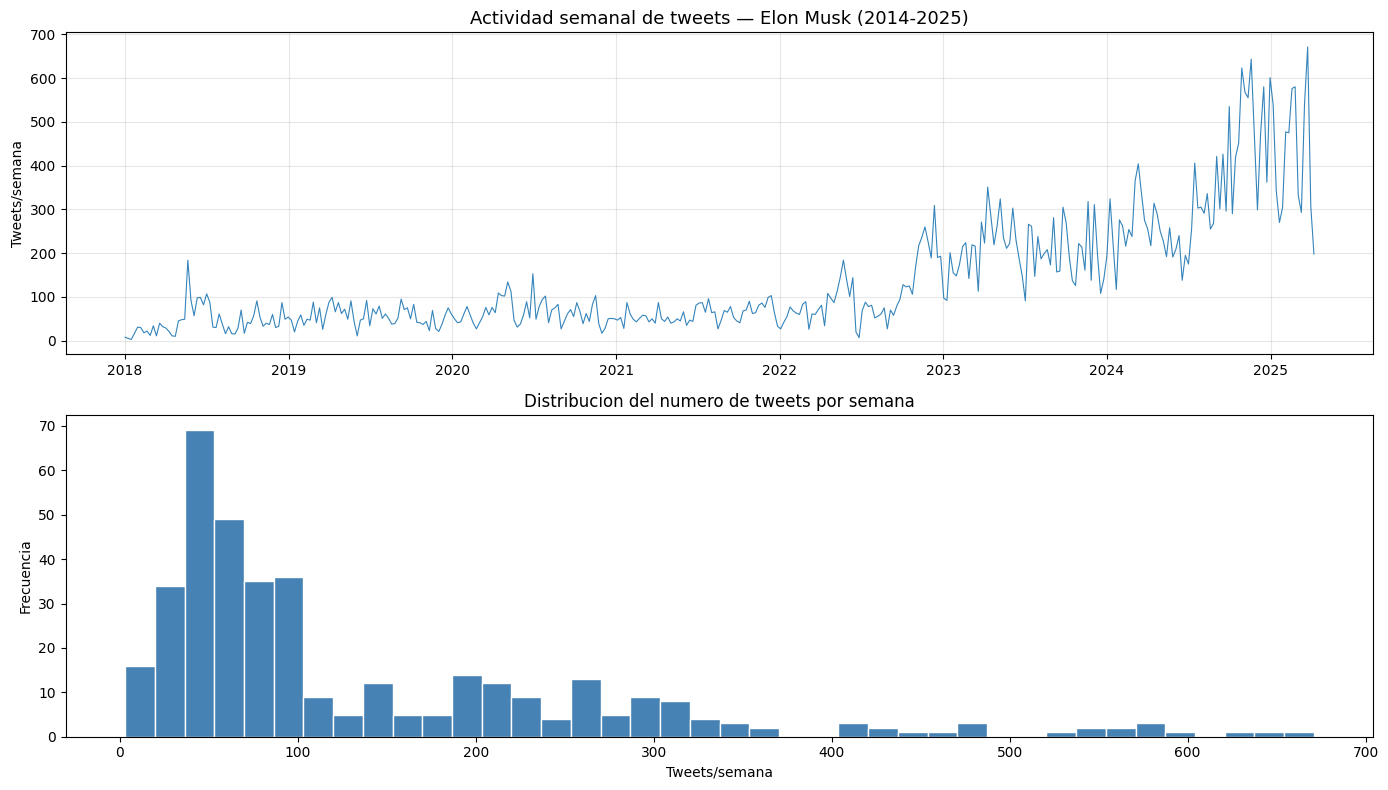

In [34]:
# Visualizar serie temporal
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(weekly['week'], weekly['tweet_count'], linewidth=0.8, alpha=0.9)
axes[0].set_title('Actividad semanal de tweets — Elon Musk (2014-2025)', fontsize=13)
axes[0].set_ylabel('Tweets/semana')
axes[0].grid(True, alpha=0.3)

axes[1].hist(weekly['tweet_count'], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Distribucion del numero de tweets por semana')
axes[1].set_xlabel('Tweets/semana')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

---
## Seccion A — Modelos Simples (Regresion Lineal, Random Forest, Red Neuronal)

Usan **4 lags** (semanas t-1 a t-4) como features en formato 2D.

### A.1 Construccion de features y split

In [35]:
N_LAGS = 6  # Mejora: 6 lags en vez de 4 para capturar mas contexto
counts = weekly['tweet_count'].values.astype(float)

X_all_simple = np.array([counts[i - N_LAGS:i] for i in range(N_LAGS, len(counts))])
y_all_simple = counts[N_LAGS:]

n       = len(X_all_simple)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train_s, y_train_s = X_all_simple[:n_train],              y_all_simple[:n_train]
X_val_s,   y_val_s   = X_all_simple[n_train:n_train+n_val], y_all_simple[n_train:n_train+n_val]
X_test_s,  y_test_s  = X_all_simple[n_train+n_val:],        y_all_simple[n_train+n_val:]

print(f'Muestras totales: {len(X_all_simple)}')
print(f'Train: {len(X_train_s)} | Val: {len(X_val_s)} | Test: {len(X_test_s)}')

Muestras totales: 374
Train: 261 | Val: 56 | Test: 57


### Modelo 1 — Regresion Lineal

In [36]:
from models.linear_regression import build_model as build_lr, count_parameters as cp_lr

lr = build_lr()
lr.fit(X_train_s, y_train_s)

n_params_lr = cp_lr(lr)
print(f'Parametros (coef + bias): {n_params_lr}')

print('\n=== Regresion Lineal ===')
for split_name, X_s, y_s in [('Train', X_train_s, y_train_s),
                               ('Val',   X_val_s,   y_val_s),
                               ('Test',  X_test_s,  y_test_s)]:
    pred = lr.predict(X_s)
    print(f'  {split_name:6s}  RMSE={rmse(y_s, pred):.2f}  MAE={mae(y_s, pred):.2f}'
          f'  R2={r2_score(y_s, pred):.4f}')

Parametros (coef + bias): 7

=== Regresion Lineal ===
  Train   RMSE=29.46  MAE=21.24  R2=0.5458
  Val     RMSE=76.55  MAE=62.07  R2=-0.4125
  Test    RMSE=120.23  MAE=95.72  R2=0.2462


### Modelo 2 — Random Forest (Mejorado)

**Mejoras:** `n_estimators=300`, `max_depth=10` — mayor capacidad expresiva y mejor generalizacion.

In [37]:
from models.random_forest import build_model as build_rf, count_parameters as cp_rf

# Mejora: mas arboles, mayor profundidad
rf = build_rf(n_estimators=300, max_depth=10, random_state=SEED)
rf.fit(X_train_s, y_train_s)

n_params_rf = cp_rf(rf)
print(f'Nodos totales en el bosque: {n_params_rf:,}')

print('\n=== Random Forest (Mejorado) ===')
for split_name, X_s, y_s in [('Train', X_train_s, y_train_s),
                               ('Val',   X_val_s,   y_val_s),
                               ('Test',  X_test_s,  y_test_s)]:
    pred = rf.predict(X_s)
    print(f'  {split_name:6s}  RMSE={rmse(y_s, pred):.2f}  MAE={mae(y_s, pred):.2f}'
          f'  R2={r2_score(y_s, pred):.4f}')

Nodos totales en el bosque: 56,456

=== Random Forest (Mejorado) ===
  Train   RMSE=14.09  MAE=10.46  R2=0.8961
  Val     RMSE=76.02  MAE=60.26  R2=-0.3930
  Test    RMSE=206.74  MAE=159.53  R2=-1.2290


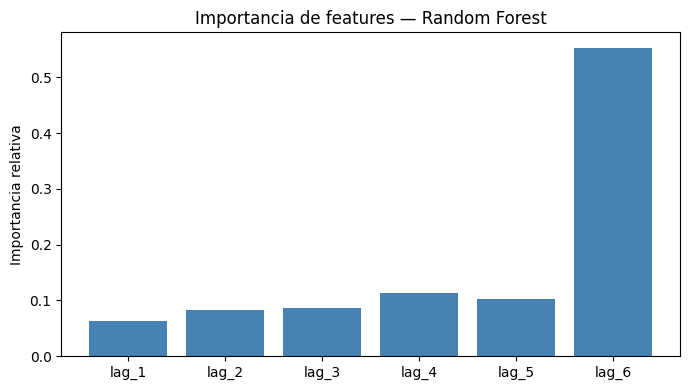

In [38]:
# Importancia de features — Random Forest
importances = rf.feature_importances_
labels = [f'lag_{i+1}' for i in range(N_LAGS)]
plt.figure(figsize=(7, 4))
plt.bar(labels, importances, color='steelblue')
plt.title('Importancia de features — Random Forest')
plt.ylabel('Importancia relativa')
plt.tight_layout()
plt.show()

### Modelo 3 — Red Neuronal Simple (Mejorada)

**Mejoras:** 3 capas ocultas (64→32→16) con BatchNormalization y Dropout(0.2). Antes era 1 capa de 2 neuronas.

In [39]:
from models.simple_nn_mejorado import build_model as build_nn, count_parameters as cp_nn

# Normalizacion con estadisticas del train
mu    = X_train_s.mean()
sigma = X_train_s.std()

X_train_n = (X_train_s - mu) / sigma
X_val_n   = (X_val_s   - mu) / sigma
X_test_n  = (X_test_s  - mu) / sigma

y_train_n = (y_train_s - mu) / sigma
y_val_n   = (y_val_s   - mu) / sigma

tf.random.set_seed(SEED)
nn_model = build_nn(n_lags=N_LAGS)  # 3 capas: 64->32->16 + BN + Dropout
nn_model.summary()
n_params_nn = cp_nn(nn_model)
print(f'\nParametros totales: {n_params_nn:,}')

Model: "SimpleNN_Mejorado"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hidden_1 (Dense)            (None, 64)                448       
                                                                 
 batch_normalization_6 (Bat  (None, 64)                256       
 chNormalization)                                                
                                                                 
 dropout_9 (Dropout)         (None, 64)                0         
                                                                 
 hidden_2 (Dense)            (None, 32)                2080      
                                                                 
 batch_normalization_7 (Bat  (None, 32)                128       
 chNormalization)                                                
                                                                 
 dropout_10 (Dropout)        (None, 32)          

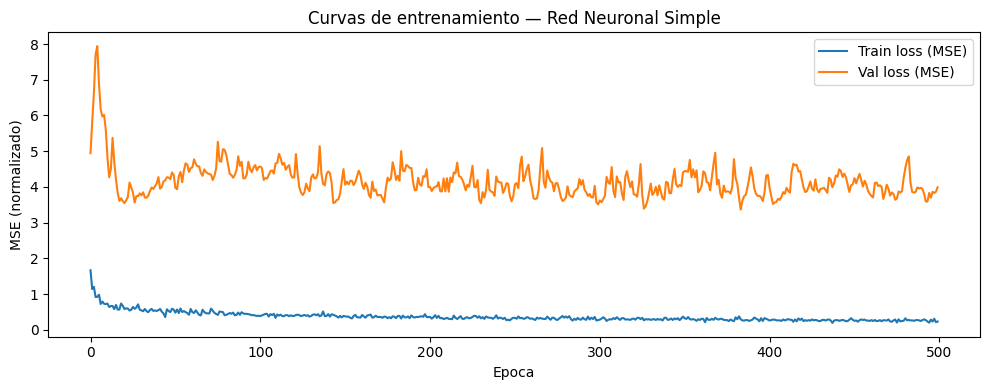

Loss final -> Train: 0.2315 | Val: 3.9886


In [40]:
history_nn = nn_model.fit(
    X_train_n, y_train_n,
    validation_data=(X_val_n, y_val_n),
    epochs=500,
    batch_size=16,
    verbose=0,
)

plt.figure(figsize=(10, 4))
plt.plot(history_nn.history['loss'],     label='Train loss (MSE)')
plt.plot(history_nn.history['val_loss'], label='Val loss (MSE)')
plt.xlabel('Epoca'); plt.ylabel('MSE (normalizado)')
plt.title('Curvas de entrenamiento — Red Neuronal Simple')
plt.legend(); plt.tight_layout(); plt.show()
print(f"Loss final -> Train: {history_nn.history['loss'][-1]:.4f} | Val: {history_nn.history['val_loss'][-1]:.4f}")

In [41]:
def eval_nn(X_norm, y_orig, split_name):
    pred = nn_model.predict(X_norm, verbose=0).flatten() * sigma + mu
    print(f'  {split_name:6s}  RMSE={rmse(y_orig, pred):.2f}  MAE={mae(y_orig, pred):.2f}'
          f'  R2={r2_score(y_orig, pred):.4f}')
    return pred

print('=== Red Neuronal Simple ===')
eval_nn(X_train_n, y_train_s, 'Train')
eval_nn(X_val_n,   y_val_s,   'Val')
eval_nn(X_test_n,  y_test_s,  'Test')
print(f'Parametros: {n_params_nn:,}')

=== Red Neuronal Simple ===
  Train   RMSE=16.38  MAE=12.54  R2=0.8595
  Val     RMSE=85.30  MAE=66.44  R2=-0.7538
  Test    RMSE=160.02  MAE=125.52  R2=-0.3353
Parametros: 3,457


### A.2 Tabla comparativa — Modelos Simples

In [42]:
results_simple = pd.DataFrame({
    'Modelo':        ['Regresion Lineal', 'Random Forest', 'Red Neuronal Simple'],
    'Params':        [n_params_lr, f'{n_params_rf:,}', n_params_nn],
    'RMSE Train':    [rmse(y_train_s, lr.predict(X_train_s)),
                      rmse(y_train_s, rf.predict(X_train_s)),
                      rmse(y_train_s, nn_model.predict(X_train_n, verbose=0).flatten() * sigma + mu)],
    'RMSE Val':      [rmse(y_val_s, lr.predict(X_val_s)),
                      rmse(y_val_s, rf.predict(X_val_s)),
                      rmse(y_val_s, nn_model.predict(X_val_n, verbose=0).flatten() * sigma + mu)],
    'RMSE Test':     [rmse(y_test_s, lr.predict(X_test_s)),
                      rmse(y_test_s, rf.predict(X_test_s)),
                      rmse(y_test_s, nn_model.predict(X_test_n, verbose=0).flatten() * sigma + mu)],
    'MAE Train':     [mae(y_train_s, lr.predict(X_train_s)),
                      mae(y_train_s, rf.predict(X_train_s)),
                      mae(y_train_s, nn_model.predict(X_train_n, verbose=0).flatten() * sigma + mu)],
    'MAE Val':       [mae(y_val_s, lr.predict(X_val_s)),
                      mae(y_val_s, rf.predict(X_val_s)),
                      mae(y_val_s, nn_model.predict(X_val_n, verbose=0).flatten() * sigma + mu)],
    'MAE Test':      [mae(y_test_s, lr.predict(X_test_s)),
                      mae(y_test_s, rf.predict(X_test_s)),
                      mae(y_test_s, nn_model.predict(X_test_n, verbose=0).flatten() * sigma + mu)],
}).round(2)

print(results_simple.to_string(index=False))

             Modelo Params  RMSE Train  RMSE Val  RMSE Test  MAE Train  MAE Val  MAE Test
   Regresion Lineal      7       29.46     76.55     120.23      21.24    62.07     95.72
      Random Forest 56,456       14.09     76.02     206.74      10.46    60.26    159.53
Red Neuronal Simple   3457       16.38     85.30     160.02      12.54    66.44    125.52


---
## Seccion B — Modelos Recurrentes (LSTM, GRU, BiLSTM+GRU, LSTM+Regimen)

Todos los modelos recurrentes usan una ventana de **16 semanas** (SEQ_LEN=16), batch_size=32 y EarlyStopping con patience=60.

Mejoras aplicadas a todos los modelos RNN:
- `SEQ_LEN`: 12 → **16** (mas contexto temporal)
- `BATCH_SIZE`: 16 → **32** (gradientes mas estables)
- `EarlyStopping patience`: 50 → **60**
- `ReduceLROnPlateau factor`: 0.3 → **0.5**, patience: 10 → **15**

### B.1 Preprocesamiento para modelos recurrentes

In [43]:
SEQ_LEN    = 16  # Mejora: 16 semanas de contexto en vez de 12
BATCH_SIZE = 32  # Mejora: batch mas grande para gradientes mas estables
EPOCHS     = 500
PATIENCE   = 60  # Mejora: mas paciencia en EarlyStopping
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15

values      = weekly['tweet_count'].values.astype(np.float32)
n_total     = len(values)
n_train_rnn = int(n_total * TRAIN_FRAC)
n_val_rnn   = int(n_total * VAL_FRAC)

train_series = values[:n_train_rnn]
val_series   = values[n_train_rnn:n_train_rnn + n_val_rnn]
test_series  = values[n_train_rnn + n_val_rnn:]

# Scaler fit SOLO sobre train (evita data leakage)
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_series.reshape(-1, 1)).flatten()
val_scaled   = scaler.transform(val_series.reshape(-1, 1)).flatten()
test_scaled  = scaler.transform(test_series.reshape(-1, 1)).flatten()

def make_windows(series, seq_len):
    X, y = [], []
    for i in range(len(series) - seq_len):
        X.append(series[i:i + seq_len])
        y.append(series[i + seq_len])
    return np.array(X)[..., np.newaxis].astype(np.float32), np.array(y, dtype=np.float32)

X_train_rnn, y_train_rnn = make_windows(train_scaled, SEQ_LEN)
X_val_rnn,   y_val_rnn   = make_windows(val_scaled,   SEQ_LEN)
X_test_rnn,  y_test_rnn  = make_windows(test_scaled,  SEQ_LEN)

print(f'Train: {len(X_train_rnn):>4} | Val: {len(X_val_rnn):>4} | Test: {len(X_test_rnn):>4}')
print(f'Shape entrada: {X_train_rnn.shape}')

Train:  250 | Val:   41 | Test:   41
Shape entrada: (250, 16, 1)


### B.2 Callbacks y funciones de evaluacion compartidas

In [44]:
def get_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=PATIENCE,  # patience=60
            restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,   # Mejora: 0.3->0.5
            patience=15, min_lr=1e-6, verbose=0  # Mejora: patience 10->15
        ),
    ]


def evaluate_split(model, X, y_true_scaled, sc, split_name):
    y_pred_scaled = model.predict(X, verbose=0).flatten()
    y_true = sc.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = sc.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    r = dict(
        split=split_name,
        RMSE=np.sqrt(mean_squared_error(y_true, y_pred)),
        MAE=mean_absolute_error(y_true, y_pred),
        R2=r2_score(y_true, y_pred),
        y_true=y_true,
        y_pred=y_pred,
    )
    print(f'  {split_name:<12} RMSE={r["RMSE"]:7.2f}  MAE={r["MAE"]:7.2f}  R2={r["R2"]:.4f}')
    return r


def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f'Perdida (MSE) — {model_name}')
    axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('MSE'); axes[0].legend()
    axes[1].plot(history.history['mae'],     label='Train MAE')
    axes[1].plot(history.history['val_mae'], label='Val MAE')
    axes[1].set_title(f'MAE — {model_name}')
    axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('MAE'); axes[1].legend()
    plt.suptitle(f'Curvas de entrenamiento — {model_name}', fontsize=14)
    plt.tight_layout(); plt.show()
    print(f'Epocas entrenadas: {len(history.history["loss"])}')


def plot_rnn_results(res_test, model_name, color):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    axes[0].plot(res_test['y_true'], label='Real',           linewidth=1.2, color='black')
    axes[0].plot(res_test['y_pred'], label=f'{model_name}',  linewidth=1.2, color=color, alpha=0.85)
    axes[0].set_title(f'Test — Real vs Prediccion {model_name}')
    axes[0].set_xlabel('Indice semana (test)'); axes[0].set_ylabel('Tweets'); axes[0].legend()
    lim = max(res_test['y_true'].max(), res_test['y_pred'].max()) * 1.05
    axes[1].scatter(res_test['y_true'], res_test['y_pred'], alpha=0.5, s=20, color=color)
    axes[1].plot([0, lim], [0, lim], 'k--', linewidth=1)
    axes[1].set_title(f'Real vs Predicho — {model_name}')
    axes[1].set_xlabel('Real'); axes[1].set_ylabel('Prediccion')
    residuals = res_test['y_true'] - res_test['y_pred']
    axes[2].bar(range(len(residuals)), residuals, color=color, alpha=0.6, width=1.0)
    axes[2].axhline(0, color='black', linewidth=0.8)
    axes[2].set_title(f'Residuos — {model_name}')
    axes[2].set_xlabel('Muestra test'); axes[2].set_ylabel('Error (tweets)')
    plt.tight_layout(); plt.show()

all_rnn_results = {}

### Modelo 4 — LSTM Apilado (Mejorado)

**Mejoras:** 2 capas LSTM apiladas (128→64 unidades) + Dense(32) + L2(0.001) + Dropout(0.3). Ventana de 16 semanas.
Antes: 1 capa LSTM(64) con Dropout(0.2).

In [45]:
from models.lstm_model_mejorado import build_lstm_model_mejorado, count_parameters as cp_lstm_s

tf.random.set_seed(SEED); np.random.seed(SEED)

lstm_model = build_lstm_model_mejorado(
    seq_len=SEQ_LEN, n_features=1,
    lstm_units_1=128, lstm_units_2=64,
    dropout=0.3, learning_rate=5e-4
)
lstm_model.summary()
n_params_lstm = lstm_model.count_params()
print(f'\nParametros totales: {n_params_lstm:,}')

Model: "LSTM_Apilado_Mejorado"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_5 (LSTM)               (None, 16, 128)           66560     
                                                                 
 dropout_11 (Dropout)        (None, 16, 128)           0         
                                                                 
 lstm_6 (LSTM)               (None, 64)                49408     
                                                                 
 batch_normalization_8 (Bat  (None, 64)                256       
 chNormalization)                                                
                                                                 
 dropout_12 (Dropout)        (None, 64)                0         
                                                                 
 dense_8 (Dense)             (None, 32)                2080      
                                             

Restoring model weights from the end of the best epoch: 107.
Epoch 167: early stopping


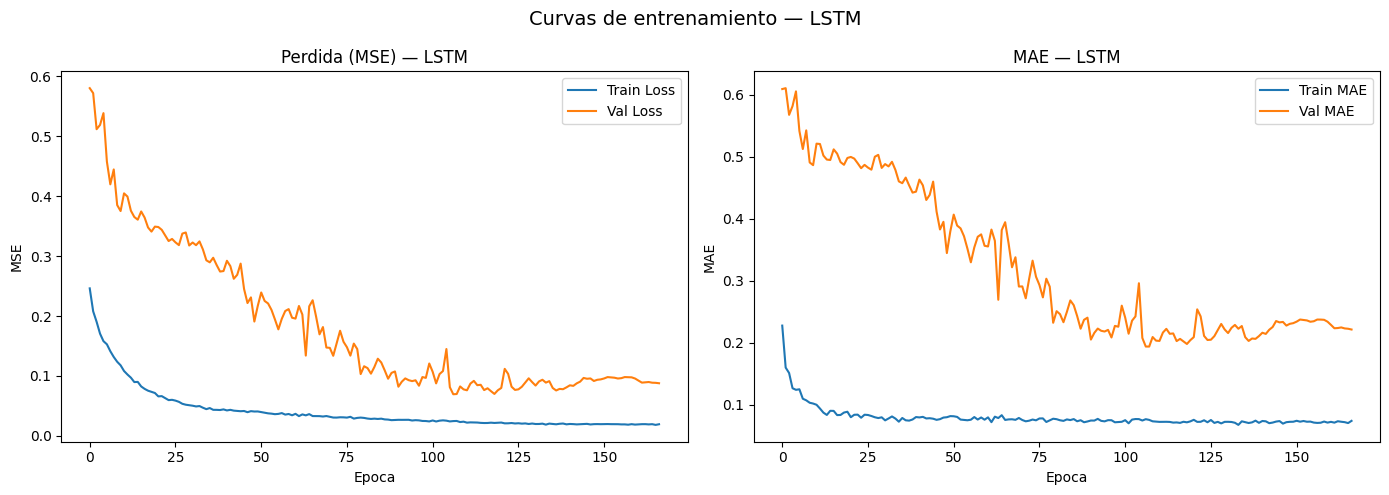

Epocas entrenadas: 167


In [46]:
history_lstm = lstm_model.fit(
    X_train_rnn, y_train_rnn,
    validation_data=(X_val_rnn, y_val_rnn),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0
)
plot_training_curves(history_lstm, 'LSTM')

Resultados LSTM (tweets/semana):
-------------------------------------------------------
  Train        RMSE=  29.82  MAE=  21.73  R2=0.5223
  Validacion   RMSE=  72.40  MAE=  59.29  R2=-0.2189
  Test         RMSE= 133.47  MAE= 113.79  R2=0.0039
-------------------------------------------------------


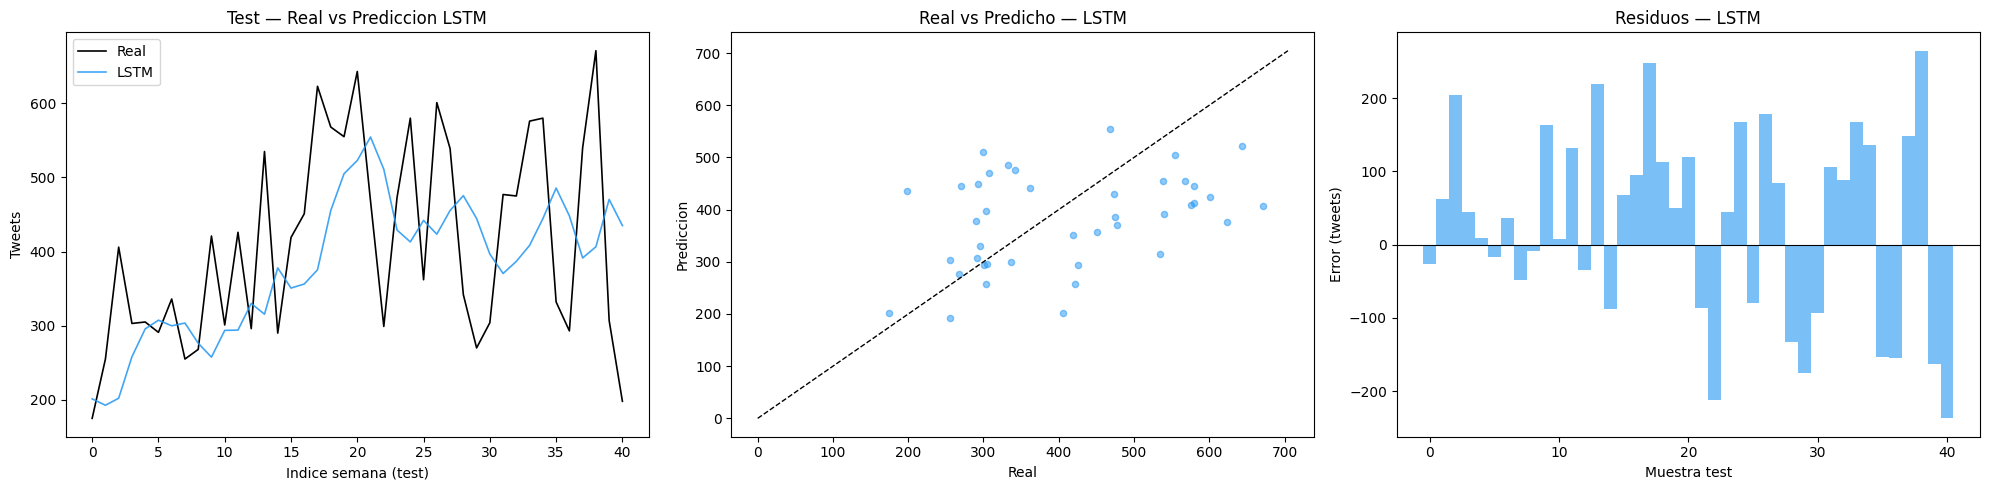

In [47]:
print('Resultados LSTM (tweets/semana):')
print('-' * 55)
res_lstm_train = evaluate_split(lstm_model, X_train_rnn, y_train_rnn, scaler, 'Train')
res_lstm_val   = evaluate_split(lstm_model, X_val_rnn,   y_val_rnn,   scaler, 'Validacion')
res_lstm_test  = evaluate_split(lstm_model, X_test_rnn,  y_test_rnn,  scaler, 'Test')
print('-' * 55)
plot_rnn_results(res_lstm_test, 'LSTM', '#2196F3')
all_rnn_results['LSTM'] = {'train': res_lstm_train, 'val': res_lstm_val,
                            'test': res_lstm_test, 'params': n_params_lstm}

### Modelo 5 — GRU Apilado (Mejorado)

**Mejoras:** 2 capas GRU apiladas (64→32 unidades) + Dense(16) + L2(0.001) + Dropout(0.3). Ventana de 16 semanas.
Antes: 1 capa GRU(32) con Dropout(0.3).

In [48]:
from models.gru_model_mejorado import build_gru_model_mejorado, count_parameters as cp_gru_s

tf.random.set_seed(SEED); np.random.seed(SEED)

gru_model = build_gru_model_mejorado(
    seq_len=SEQ_LEN, n_features=1,
    gru_units_1=64, gru_units_2=32,
    dropout=0.3, learning_rate=5e-4
)
gru_model.summary()
n_params_gru = gru_model.count_params()
print(f'\nParametros totales: {n_params_gru:,}')

Model: "GRU_Apilado_Mejorado"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_3 (GRU)                 (None, 16, 64)            12864     
                                                                 
 dropout_13 (Dropout)        (None, 16, 64)            0         
                                                                 
 gru_4 (GRU)                 (None, 32)                9408      
                                                                 
 batch_normalization_9 (Bat  (None, 32)                128       
 chNormalization)                                                
                                                                 
 dropout_14 (Dropout)        (None, 32)                0         
                                                                 
 dense_10 (Dense)            (None, 16)                528       
                                              

Restoring model weights from the end of the best epoch: 109.
Epoch 169: early stopping


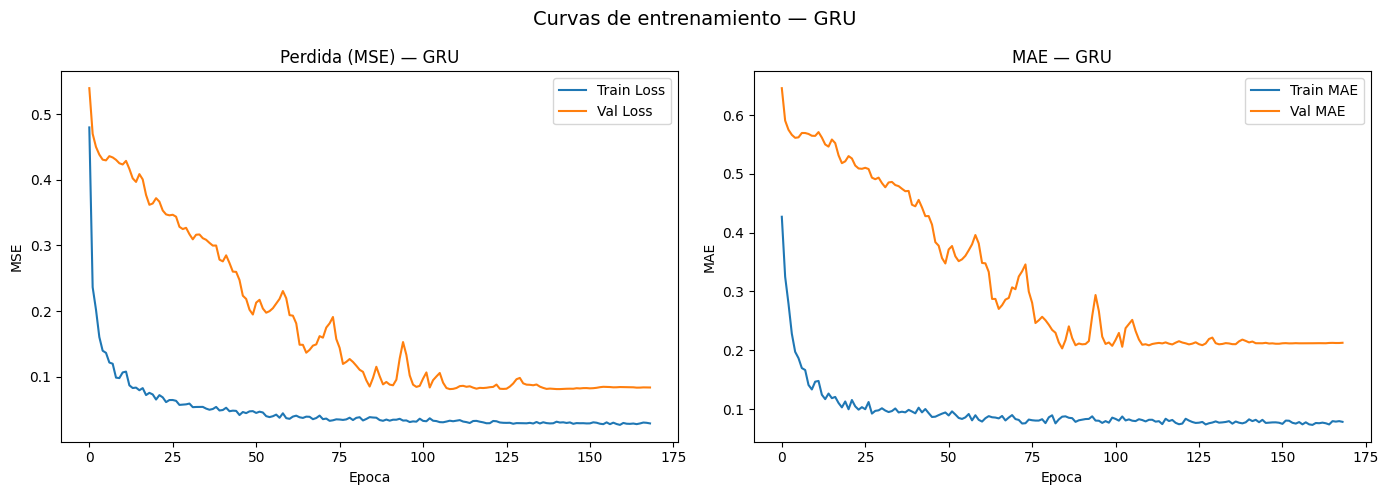

Epocas entrenadas: 169


In [49]:
history_gru = gru_model.fit(
    X_train_rnn, y_train_rnn,
    validation_data=(X_val_rnn, y_val_rnn),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0
)
plot_training_curves(history_gru, 'GRU')

Resultados GRU (tweets/semana):
-------------------------------------------------------
  Train        RMSE=  33.62  MAE=  26.48  R2=0.3926
  Validacion   RMSE=  76.02  MAE=  64.08  R2=-0.3436
  Test         RMSE= 134.58  MAE= 113.65  R2=-0.0127
-------------------------------------------------------


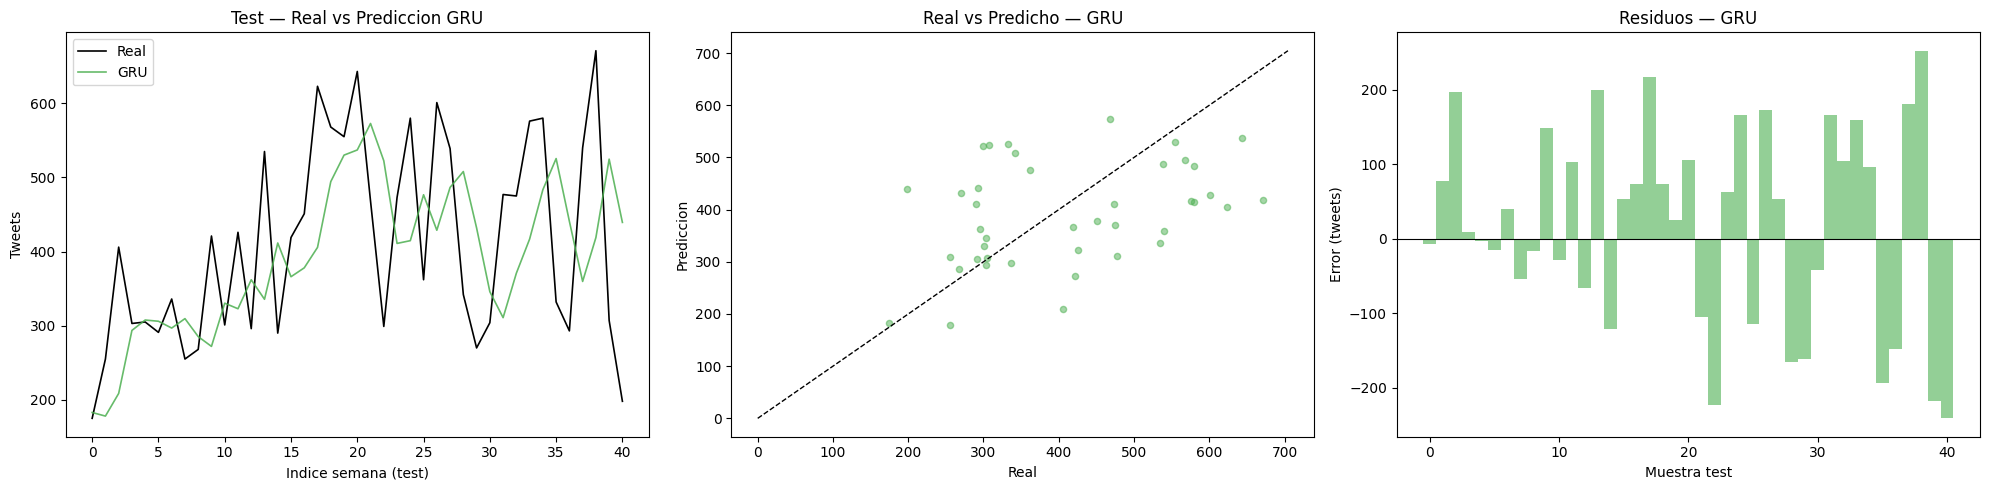

In [50]:
print('Resultados GRU (tweets/semana):')
print('-' * 55)
res_gru_train = evaluate_split(gru_model, X_train_rnn, y_train_rnn, scaler, 'Train')
res_gru_val   = evaluate_split(gru_model, X_val_rnn,   y_val_rnn,   scaler, 'Validacion')
res_gru_test  = evaluate_split(gru_model, X_test_rnn,  y_test_rnn,  scaler, 'Test')
print('-' * 55)
plot_rnn_results(res_gru_test, 'GRU', '#4CAF50')
all_rnn_results['GRU'] = {'train': res_gru_train, 'val': res_gru_val,
                           'test': res_gru_test, 'params': n_params_gru}

### Modelo 6 — BiLSTM + GRU (Mejorado)

**Mejoras:** 64 unidades (antes 32) en BiLSTM y GRU + BatchNorm + Dense(32) + L2(0.001). Ventana de 16 semanas.
Antes: BiLSTM(32) + GRU(32).

In [51]:
from models.lstm_gru_model_mejorado import build_lstm_gru_model_mejorado, count_parameters as cp_bilstm

tf.random.set_seed(SEED); np.random.seed(SEED)

bilstm_gru_model = build_lstm_gru_model_mejorado(
    seq_len=SEQ_LEN, n_features=1,
    units=64, dropout=0.3, learning_rate=5e-4
)
bilstm_gru_model.summary()
n_params_bilstm = bilstm_gru_model.count_params()
print(f'\nParametros totales: {n_params_bilstm:,}')

Model: "BiLSTM_GRU_Mejorado"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_1 (Bidirecti  (None, 16, 128)           33792     
 onal)                                                           
                                                                 
 gru_5 (GRU)                 (None, 64)                37248     
                                                                 
 batch_normalization_10 (Ba  (None, 64)                256       
 tchNormalization)                                               
                                                                 
 dropout_15 (Dropout)        (None, 64)                0         
                                                                 
 dense_12 (Dense)            (None, 32)                2080      
                                                                 
 dense_13 (Dense)            (None, 1)         

Restoring model weights from the end of the best epoch: 138.
Epoch 198: early stopping


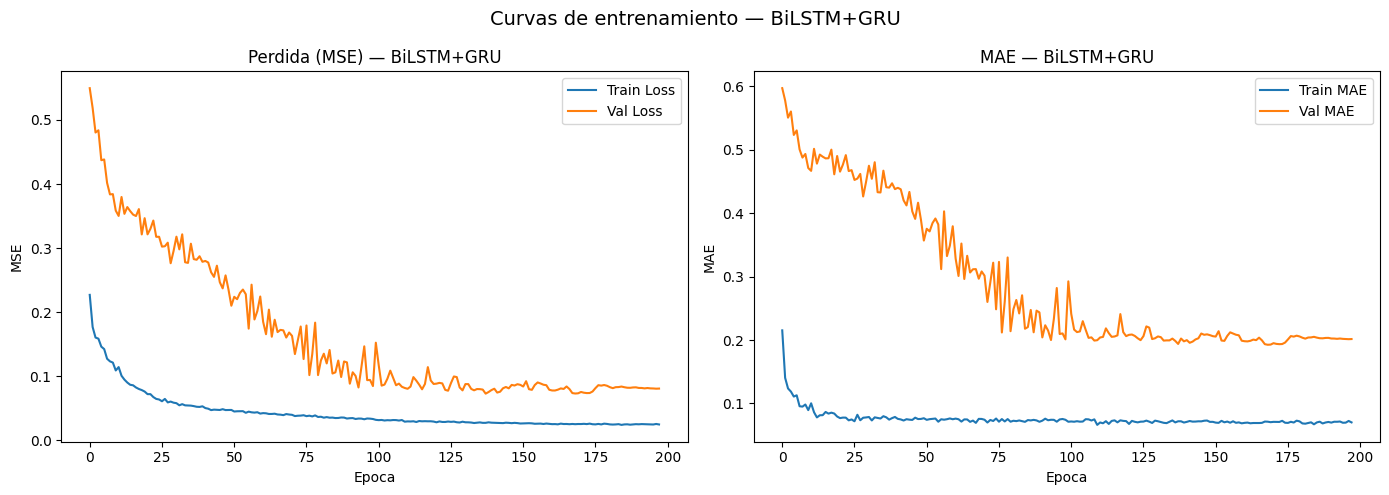

Epocas entrenadas: 198


In [52]:
history_bilstm = bilstm_gru_model.fit(
    X_train_rnn, y_train_rnn,
    validation_data=(X_val_rnn, y_val_rnn),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0
)
plot_training_curves(history_bilstm, 'BiLSTM+GRU')

Resultados BiLSTM+GRU (tweets/semana):
-------------------------------------------------------
  Train        RMSE=  29.47  MAE=  22.54  R2=0.5335
  Validacion   RMSE=  71.62  MAE=  59.35  R2=-0.1926
  Test         RMSE= 134.36  MAE= 113.85  R2=-0.0094
-------------------------------------------------------


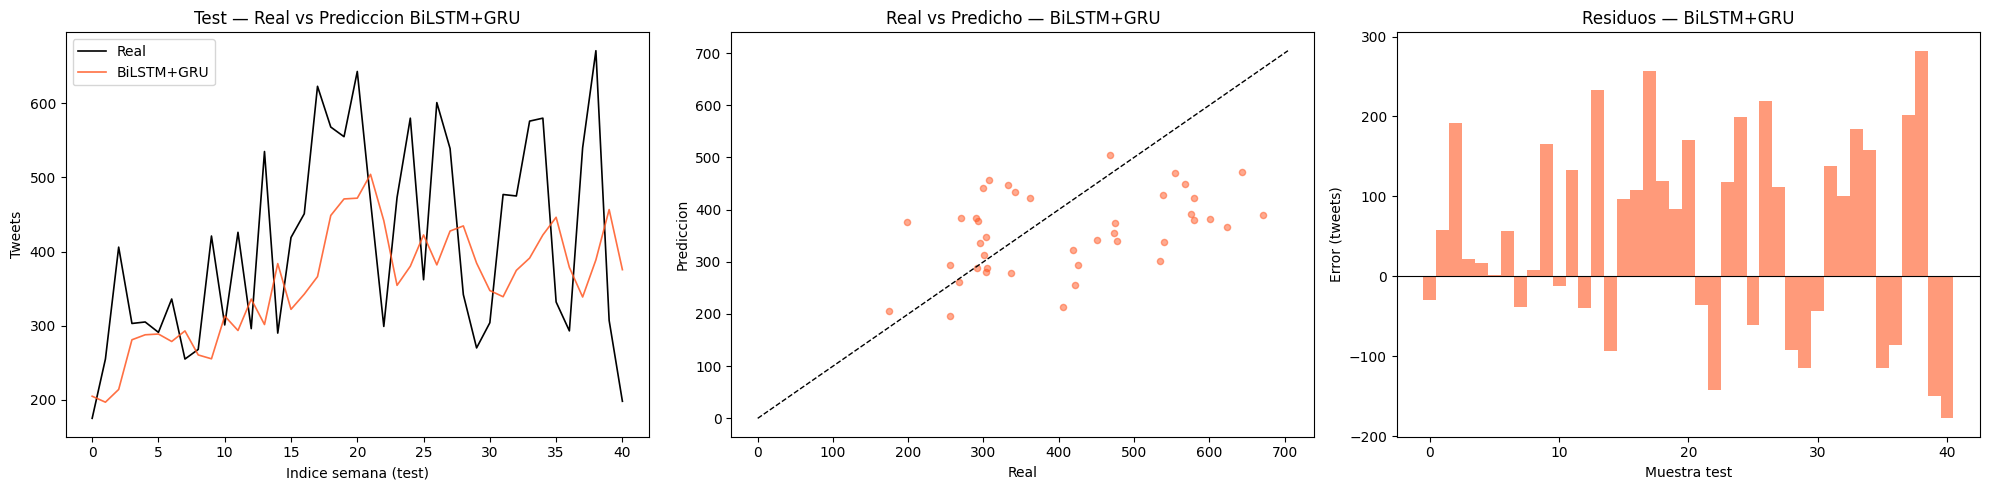

In [53]:
print('Resultados BiLSTM+GRU (tweets/semana):')
print('-' * 55)
res_bi_train = evaluate_split(bilstm_gru_model, X_train_rnn, y_train_rnn, scaler, 'Train')
res_bi_val   = evaluate_split(bilstm_gru_model, X_val_rnn,   y_val_rnn,   scaler, 'Validacion')
res_bi_test  = evaluate_split(bilstm_gru_model, X_test_rnn,  y_test_rnn,  scaler, 'Test')
print('-' * 55)
plot_rnn_results(res_bi_test, 'BiLSTM+GRU', '#FF5722')
all_rnn_results['BiLSTM+GRU'] = {'train': res_bi_train, 'val': res_bi_val,
                                   'test': res_bi_test, 'params': n_params_bilstm}

### Modelo 7 — LSTM Apilado + Variable de Regimen (Mejorado)

Anade una feature binaria `post_acquisition` (0=antes, 1=despues de oct-2022) para modelar el cambio de comportamiento tras la adquisicion de Twitter.

**Mejoras:** Mismo LSTM apilado mejorado (128→64) con n_features=2. Ventana de 16 semanas.
Antes: LSTM simple(32) con n_features=2.

Semanas pre-adquisicion:  252
Semanas post-adquisicion: 128


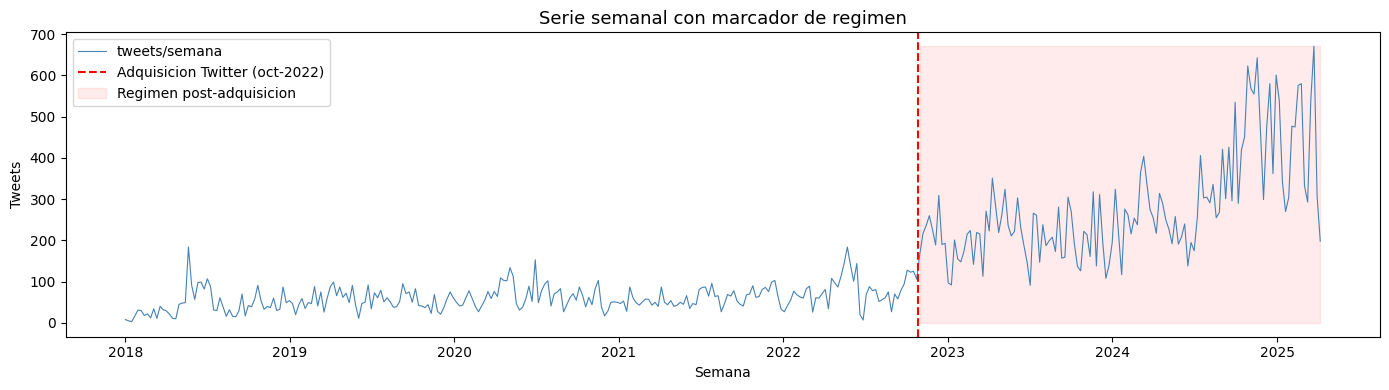

Media pre-adquisicion:  60.2
Media post-adquisicion: 280.7


In [54]:
# Variable de regimen
ACQUISITION_DATE = pd.Timestamp('2022-10-27')
weekly['post_acquisition'] = (weekly['week'] >= ACQUISITION_DATE).astype(np.float32)

print(f'Semanas pre-adquisicion:  {(weekly.post_acquisition == 0).sum()}')
print(f'Semanas post-adquisicion: {(weekly.post_acquisition == 1).sum()}')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(weekly['week'], weekly['tweet_count'], linewidth=0.8, color='steelblue', label='tweets/semana')
ax.axvline(ACQUISITION_DATE, color='red', linestyle='--', linewidth=1.5, label='Adquisicion Twitter (oct-2022)')
ax.fill_between(weekly['week'], 0, weekly['tweet_count'].max(),
                where=(weekly['post_acquisition'] == 1),
                alpha=0.08, color='red', label='Regimen post-adquisicion')
ax.set_title('Serie semanal con marcador de regimen', fontsize=13)
ax.set_xlabel('Semana'); ax.set_ylabel('Tweets'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Media pre-adquisicion:  {weekly[weekly.post_acquisition==0]["tweet_count"].mean():.1f}')
print(f'Media post-adquisicion: {weekly[weekly.post_acquisition==1]["tweet_count"].mean():.1f}')

In [55]:
# Preprocesamiento multivariante (2 features: tweet_count + post_acquisition)
n_total_r = len(weekly)
n_train_r = int(n_total_r * TRAIN_FRAC)
n_val_r   = int(n_total_r * VAL_FRAC)

train_df = weekly.iloc[:n_train_r].copy()
val_df   = weekly.iloc[n_train_r:n_train_r + n_val_r].copy()
test_df  = weekly.iloc[n_train_r + n_val_r:].copy()

print(f'Train: {len(train_df)} semanas  ({train_df.week.min().date()} -> {train_df.week.max().date()})')
print(f'Val:   {len(val_df)} semanas  ({val_df.week.min().date()} -> {val_df.week.max().date()})')
print(f'Test:  {len(test_df)} semanas  ({test_df.week.min().date()} -> {test_df.week.max().date()})')

scaler_regime = MinMaxScaler()
train_counts_r = scaler_regime.fit_transform(train_df[['tweet_count']]).flatten()
val_counts_r   = scaler_regime.transform(val_df[['tweet_count']]).flatten()
test_counts_r  = scaler_regime.transform(test_df[['tweet_count']]).flatten()

def build_multivariate(counts_scaled, regime_values):
    return np.stack([counts_scaled, regime_values.astype(np.float32)], axis=1)

train_arr = build_multivariate(train_counts_r, train_df['post_acquisition'].values)
val_arr   = build_multivariate(val_counts_r,   val_df['post_acquisition'].values)
test_arr  = build_multivariate(test_counts_r,  test_df['post_acquisition'].values)

def make_windows_multi(arr, seq_len):
    X, y = [], []
    for i in range(len(arr) - seq_len):
        X.append(arr[i:i + seq_len])
        y.append(arr[i + seq_len, 0])  # target = tweet_count normalizado
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train_reg, y_train_reg = make_windows_multi(train_arr, SEQ_LEN)
X_val_reg,   y_val_reg   = make_windows_multi(val_arr,   SEQ_LEN)
X_test_reg,  y_test_reg  = make_windows_multi(test_arr,  SEQ_LEN)

print(f'Train: {X_train_reg.shape} | Val: {X_val_reg.shape} | Test: {X_test_reg.shape}')

Train: 266 semanas  (2018-01-01 -> 2023-01-30)
Val:   57 semanas  (2023-02-06 -> 2024-03-04)
Test:  57 semanas  (2024-03-11 -> 2025-04-07)
Train: (250, 16, 2) | Val: (41, 16, 2) | Test: (41, 16, 2)


In [56]:
from models.lstm_model_mejorado import build_lstm_model_mejorado

tf.random.set_seed(SEED); np.random.seed(SEED)

lstm_regime_model = build_lstm_model_mejorado(
    seq_len=SEQ_LEN,
    n_features=2,           # tweet_count + post_acquisition
    lstm_units_1=128,
    lstm_units_2=64,
    dropout=0.3,
    learning_rate=5e-4,
)
lstm_regime_model.summary()
n_params_regime = lstm_regime_model.count_params()
print(f'\nParametros totales: {n_params_regime:,}')

Model: "LSTM_Apilado_Mejorado"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_8 (LSTM)               (None, 16, 128)           67072     
                                                                 
 dropout_16 (Dropout)        (None, 16, 128)           0         
                                                                 
 lstm_9 (LSTM)               (None, 64)                49408     
                                                                 
 batch_normalization_11 (Ba  (None, 64)                256       
 tchNormalization)                                               
                                                                 
 dropout_17 (Dropout)        (None, 64)                0         
                                                                 
 dense_14 (Dense)            (None, 32)                2080      
                                             

Restoring model weights from the end of the best epoch: 106.
Epoch 166: early stopping


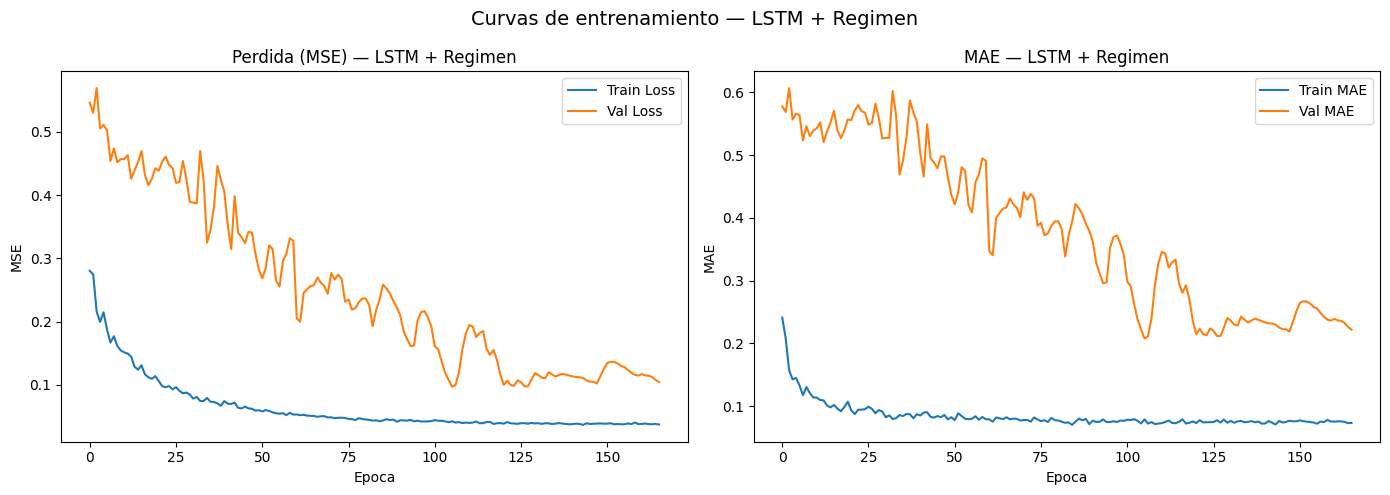

Epocas entrenadas: 166


In [57]:
history_regime = lstm_regime_model.fit(
    X_train_reg, y_train_reg,
    validation_data=(X_val_reg, y_val_reg),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0
)
plot_training_curves(history_regime, 'LSTM + Regimen')

Resultados LSTM + Regimen (tweets/semana):
-------------------------------------------------------
  Train        RMSE=  28.84  MAE=  21.62  R2=0.5532
  Validacion   RMSE=  78.72  MAE=  63.57  R2=-0.4406
  Test         RMSE= 245.17  MAE= 208.24  R2=-2.3612
-------------------------------------------------------


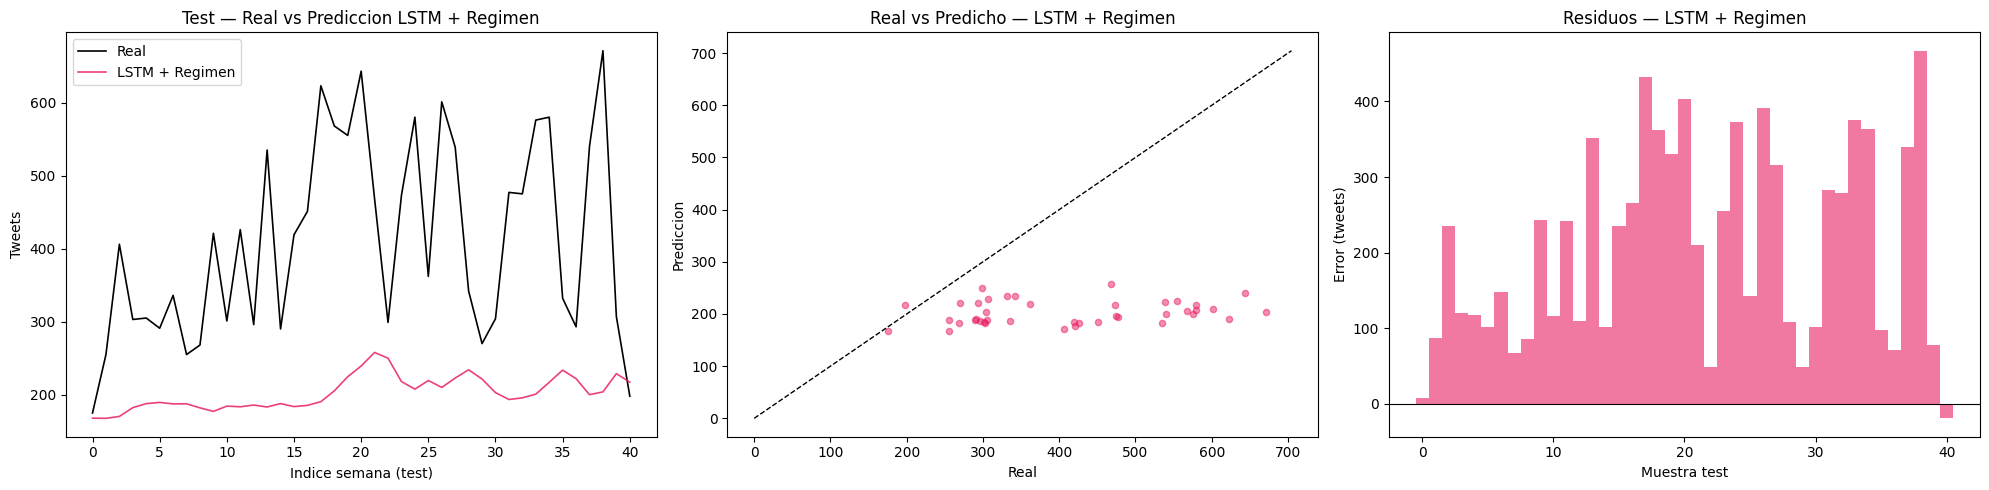

In [58]:
print('Resultados LSTM + Regimen (tweets/semana):')
print('-' * 55)
res_reg_train = evaluate_split(lstm_regime_model, X_train_reg, y_train_reg, scaler_regime, 'Train')
res_reg_val   = evaluate_split(lstm_regime_model, X_val_reg,   y_val_reg,   scaler_regime, 'Validacion')
res_reg_test  = evaluate_split(lstm_regime_model, X_test_reg,  y_test_reg,  scaler_regime, 'Test')
print('-' * 55)
plot_rnn_results(res_reg_test, 'LSTM + Regimen', '#E91E63')
all_rnn_results['LSTM + Regimen'] = {'train': res_reg_train, 'val': res_reg_val,
                                      'test': res_reg_test, 'params': n_params_regime}

---
## Comparativa final — Todos los modelos

In [59]:
rows = []

# Modelos simples
for name, X_tr, X_vl, X_te, y_tr, y_vl, y_te, params, is_nn in [
    ('Regresion Lineal',    X_train_s, X_val_s, X_test_s,
     y_train_s, y_val_s, y_test_s, n_params_lr, False),
    ('Random Forest',       X_train_s, X_val_s, X_test_s,
     y_train_s, y_val_s, y_test_s, n_params_rf, False),
    ('Red Neuronal Simple', X_train_n, X_val_n, X_test_n,
     y_train_s, y_val_s, y_test_s, n_params_nn, True),
]:
    if is_nn:
        p_tr = nn_model.predict(X_tr, verbose=0).flatten() * sigma + mu
        p_vl = nn_model.predict(X_vl, verbose=0).flatten() * sigma + mu
        p_te = nn_model.predict(X_te, verbose=0).flatten() * sigma + mu
    else:
        model_obj = lr if name == 'Regresion Lineal' else rf
        p_tr = model_obj.predict(X_tr)
        p_vl = model_obj.predict(X_vl)
        p_te = model_obj.predict(X_te)

    rows.append({
        'Modelo':      name,
        'Params':      params,
        'RMSE Train':  round(rmse(y_tr, p_tr), 2),
        'RMSE Val':    round(rmse(y_vl, p_vl), 2),
        'RMSE Test':   round(rmse(y_te, p_te), 2),
        'MAE Train':   round(mae(y_tr, p_tr),  2),
        'MAE Val':     round(mae(y_vl, p_vl),  2),
        'MAE Test':    round(mae(y_te, p_te),  2),
        'R2 Train':    round(r2_score(y_tr, p_tr), 4),
        'R2 Val':      round(r2_score(y_vl, p_vl), 4),
        'R2 Test':     round(r2_score(y_te, p_te), 4),
    })

# Modelos RNN
for name, data in all_rnn_results.items():
    rows.append({
        'Modelo':      name,
        'Params':      f"{data['params']:,}",
        'RMSE Train':  round(data['train']['RMSE'], 2),
        'RMSE Val':    round(data['val']['RMSE'],   2),
        'RMSE Test':   round(data['test']['RMSE'],  2),
        'MAE Train':   round(data['train']['MAE'],  2),
        'MAE Val':     round(data['val']['MAE'],    2),
        'MAE Test':    round(data['test']['MAE'],   2),
        'R2 Train':    round(data['train']['R2'],   4),
        'R2 Val':      round(data['val']['R2'],     4),
        'R2 Test':     round(data['test']['R2'],    4),
    })

final_comparison = pd.DataFrame(rows)
print('=' * 100)
print('COMPARACION FINAL — MODELOS SEMANAL')
print('=' * 100)
print(final_comparison.to_string(index=False))
print()
best_rmse = final_comparison.loc[final_comparison['RMSE Test'].idxmin(), 'Modelo']
best_r2   = final_comparison.loc[final_comparison['R2 Test'].idxmax(),   'Modelo']
print(f'Mejor RMSE Test: {best_rmse}')
print(f'Mejor R2 Test:   {best_r2}')

COMPARACION FINAL — MODELOS SEMANAL
             Modelo  Params  RMSE Train  RMSE Val  RMSE Test  MAE Train  MAE Val  MAE Test  R2 Train  R2 Val  R2 Test
   Regresion Lineal       7       29.46     76.55     120.23      21.24    62.07     95.72    0.5458 -0.4125   0.2462
      Random Forest   56456       14.09     76.02     206.74      10.46    60.26    159.53    0.8961 -0.3930  -1.2290
Red Neuronal Simple    3457       16.38     85.30     160.02      12.54    66.44    125.52    0.8595 -0.7538  -0.3353
               LSTM 118,337       29.82     72.40     133.47      21.73    59.29    113.79    0.5223 -0.2189   0.0039
                GRU  22,945       33.62     76.02     134.58      26.48    64.08    113.65    0.3926 -0.3436  -0.0127
         BiLSTM+GRU  73,409       29.47     71.62     134.36      22.54    59.35    113.85    0.5335 -0.1926  -0.0094
     LSTM + Regimen 118,849       28.84     78.72     245.17      21.62    63.57    208.24    0.5532 -0.4406  -2.3612

Mejor RMSE Test: Re

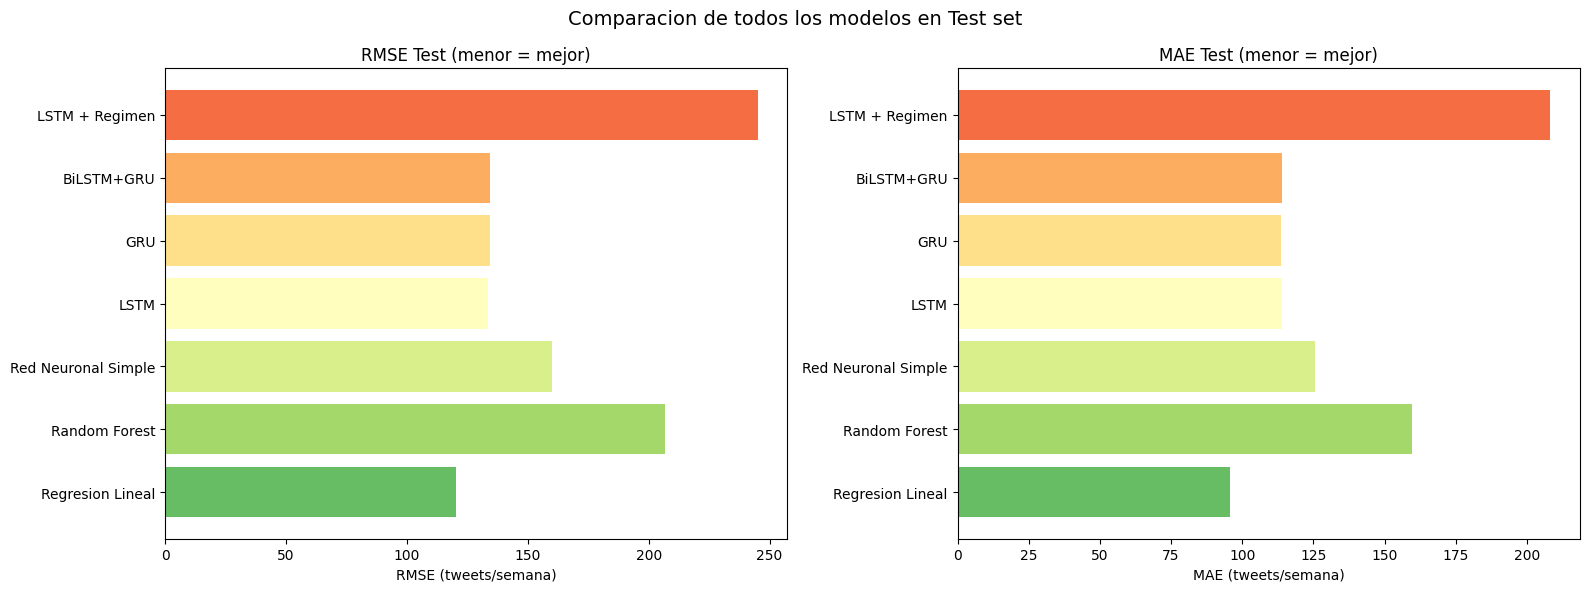

In [60]:
# Grafico comparativo de barras
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
models_names = final_comparison['Modelo'].values
rmse_vals    = final_comparison['RMSE Test'].astype(float).values
mae_vals     = final_comparison['MAE Test'].astype(float).values
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(models_names)))

axes[0].barh(range(len(models_names)), rmse_vals, color=colors)
axes[0].set_yticks(range(len(models_names)))
axes[0].set_yticklabels(models_names)
axes[0].set_title('RMSE Test (menor = mejor)')
axes[0].set_xlabel('RMSE (tweets/semana)')

axes[1].barh(range(len(models_names)), mae_vals, color=colors)
axes[1].set_yticks(range(len(models_names)))
axes[1].set_yticklabels(models_names)
axes[1].set_title('MAE Test (menor = mejor)')
axes[1].set_xlabel('MAE (tweets/semana)')

plt.suptitle('Comparacion de todos los modelos en Test set', fontsize=14)
plt.tight_layout()
plt.show()